In [2]:
%load_ext autoreload
%autoreload 2
%env ANYWIDGET_HMR=1

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
env: ANYWIDGET_HMR=1


In [3]:
# # leiden clustering requires:
# ! pip install igraph
# ! pip install leidenalg

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import scanpy as sc
import squidpy as sq
import spatialdata as sd
import celldega as dega
from ipywidgets import Widget
from spatialdata_io import xenium

import warnings
warnings.filterwarnings("ignore")

dega.__version__

'0.8.2'

In [7]:
# dataset_name = 'Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_outs'
dataset_name = 'Xenium_V1_human_Pancreas_FFPE_outs'
sample = dataset_name
tech = 'Xenium'
print (tech)

DATA_DIR = f'../data'
data_dir = f'{DATA_DIR}/{dataset_name}'
path_landscape_files = f'landscape_files/{dataset_name}'

Xenium


## Ingest Xenium data using spatialdata-io
- raw output to zarr file (spatialdata-io)
- zarr to spatialdata to adata (spatialdata)

In [54]:
# Ingest xenium data raw output folder using spatialdata-io
sdata = xenium(data_dir)

# Write sdata to a zarr file
zarr_path = f"{data_dir}.zarr"

# Check if the zarr file already exists
if os.path.exists(zarr_path):
    print(f"The file {zarr_path} already exists.")
else:
    # If the file does not exist, write the data
    sdata.write(zarr_path)
    print(f"Data written to {zarr_path} successfully.")

# Read zarr file using spatialdata
sdata = sd.read_zarr(zarr_path)

# Create anndata from sdata.tables['table]
adata = sdata.tables["table"]

INFO     reading ../data/Xenium_V1_human_Pancreas_FFPE_outs/cell_feature_matrix.h5                                 


/var/folders/l8/d8mkns3s3w57r6pv37msmmcm0000gp/T/ipykernel_790/2246102908.py:2: DeprecationWarning: The default value of `cells_as_circles` will change to `False` in the next release. Please pass `True` explicitly to maintain the current behavior.
  sdata = xenium(data_dir)


The file ../data/Xenium_V1_human_Pancreas_FFPE_outs.zarr already exists.


/Users/whuan/opt/anaconda3/envs/celldega_env/lib/python3.11/site-packages/zarr/creation.py:300: UserWarning: ignoring keyword argument 'read_only'
  warn(f"ignoring keyword argument {k!r}")
/Users/whuan/opt/anaconda3/envs/celldega_env/lib/python3.11/site-packages/zarr/creation.py:300: UserWarning: ignoring keyword argument 'read_only'
  warn(f"ignoring keyword argument {k!r}")
/Users/whuan/opt/anaconda3/envs/celldega_env/lib/python3.11/site-packages/zarr/creation.py:300: UserWarning: ignoring keyword argument 'read_only'
  warn(f"ignoring keyword argument {k!r}")
/Users/whuan/opt/anaconda3/envs/celldega_env/lib/python3.11/site-packages/zarr/creation.py:300: UserWarning: ignoring keyword argument 'read_only'
  warn(f"ignoring keyword argument {k!r}")
/Users/whuan/opt/anaconda3/envs/celldega_env/lib/python3.11/site-packages/zarr/creation.py:300: UserWarning: ignoring keyword argument 'read_only'
  warn(f"ignoring keyword argument {k!r}")
/Users/whuan/opt/anaconda3/envs/celldega_env/lib/p

## Initial QC

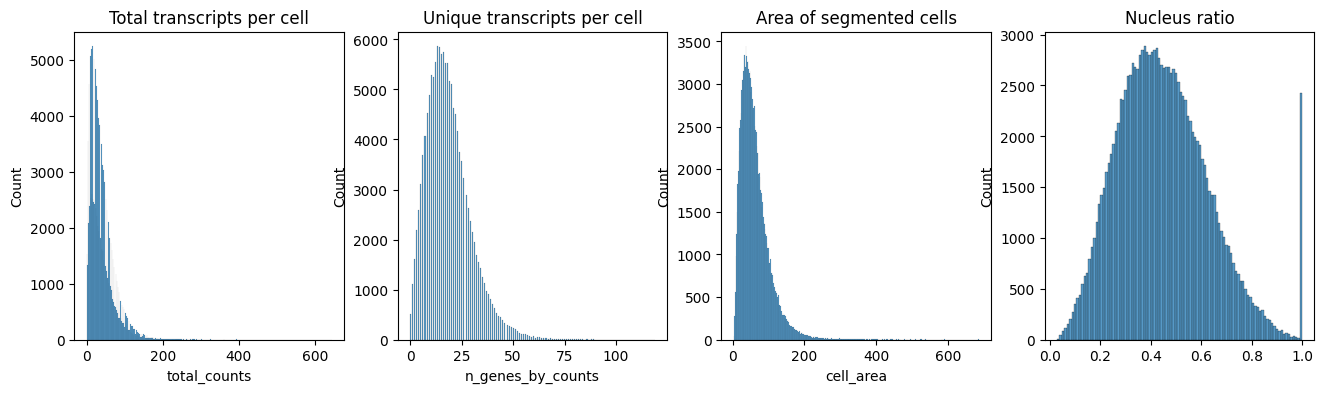

In [ ]:
# Calculate QC metrics
sc.pp.calculate_qc_metrics(adata, percent_top=(10, 20, 50, 150), inplace=True)

cprobes = (
    adata.obs["control_probe_counts"].sum() / adata.obs["total_counts"].sum() * 100
)
cwords = (
    adata.obs["control_codeword_counts"].sum() / adata.obs["total_counts"].sum() * 100
)
print(f"Negative DNA probe count % : {cprobes}")
print(f"Negative decoding count % : {cwords}")

def plot_qc_metrics(adata):
    # Define the metrics to plot
    metrics = [
        ("total_counts", "Total transcripts per cell"),
        ("n_genes_by_counts", "Unique transcripts per cell"),
        ("cell_area", "Area of segmented cells"),
        ("nucleus_area", "Nucleus ratio")
    ]

    # Create a subplot for each metric
    fig, axs = plt.subplots(1, 4, figsize=(16, 4))

    for ax, (metric, title) in zip(axs, metrics):
        # Handle special case for nucleus ratio
        if metric == "nucleus_area":
            data = adata.obs["nucleus_area"] / adata.obs["cell_area"]
        else:
            data = adata.obs[metric]
        
        # Plot the histogram
        sns.histplot(data, kde=False, ax=ax)
        ax.set_title(title)
    
    plt.show()

# Usage
plot_qc_metrics(adata)

# Filter cells and genes
sc.pp.filter_cells(adata, min_counts=10)
sc.pp.filter_genes(adata, min_cells=5)

# Keep raw
adata.layers["counts"] = adata.X.copy()

## Scanpy preprocessing
- normalize, log1p, pca, neighbors, umap, leiden

In [ ]:
# Derived data
sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(adata)


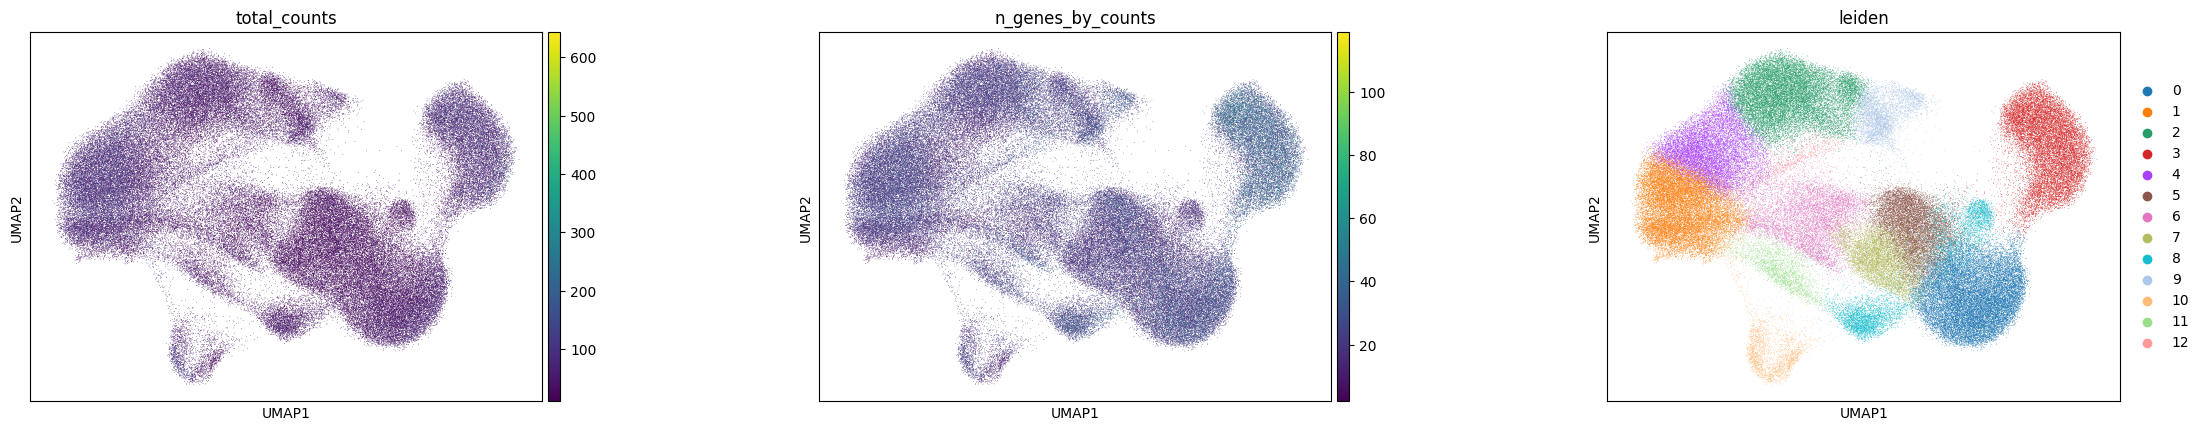

/Users/whuan/opt/anaconda3/envs/celldega_env/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


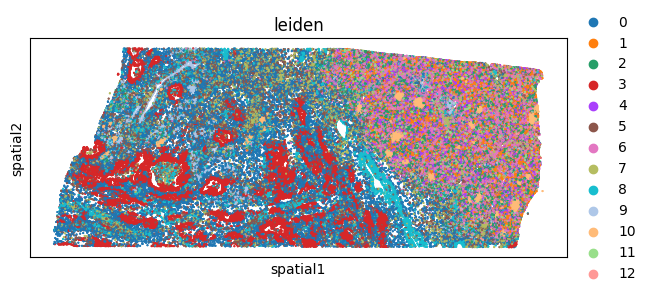

In [ ]:
# Plotting 
sc.pl.umap(
    adata,
    color=[
        "total_counts",
        "n_genes_by_counts",
        "leiden",
    ],
    wspace=0.4,
)

sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    shape=None,
    color=[
        "leiden",
    ],
    wspace=0.4,
)

## Export adata to h5ad file

In [ ]:
# # Write h5ad files
# adata.write_h5ad(f'{data_dir}.h5ad')

## Visualize Spatial/UMAP/Staining and heatmap simultaneously

In [13]:
# Load h5ad file
adata = sc.read_h5ad(f'{data_dir}.h5ad')
adata.obs.set_index('cell_id', inplace=True)

# Prepare data for Landscape-Matrix view
args_derived_from_adata = dega.pre.prep_landscape_matrix_from_adata(adata)

# Create landscape_ist, mat instances 
Widget.close_all()
technology='Xenium'
server_address = dega.viz.get_local_server()
mat = dega.viz.Matrix(network=args_derived_from_adata['network'], width=500, height=500)
landscape_ist = dega.viz.Landscape(
    technology=technology, 
    height=600,
    base_url = f"http://localhost:{server_address}/{path_landscape_files}",
    meta_cell = args_derived_from_adata['meta_cell'],
    meta_cluster = args_derived_from_adata['meta_cluster'],
    umap=args_derived_from_adata['umap'],
    landscape_state='umap',
)

# Visualize
dega.viz.landscape_matrix(landscape_ist, mat)

Server running on port 59004


## Build neighborhood graph

In [43]:
# Building a spatial neighborhood graph 
sq.gr.spatial_neighbors(adata, coord_type="generic", delaunay=True)

## Compute centrality score
Centrality scores are calculated with squidpy.gr.centrality_scores, with the Leiden groups as clusters.

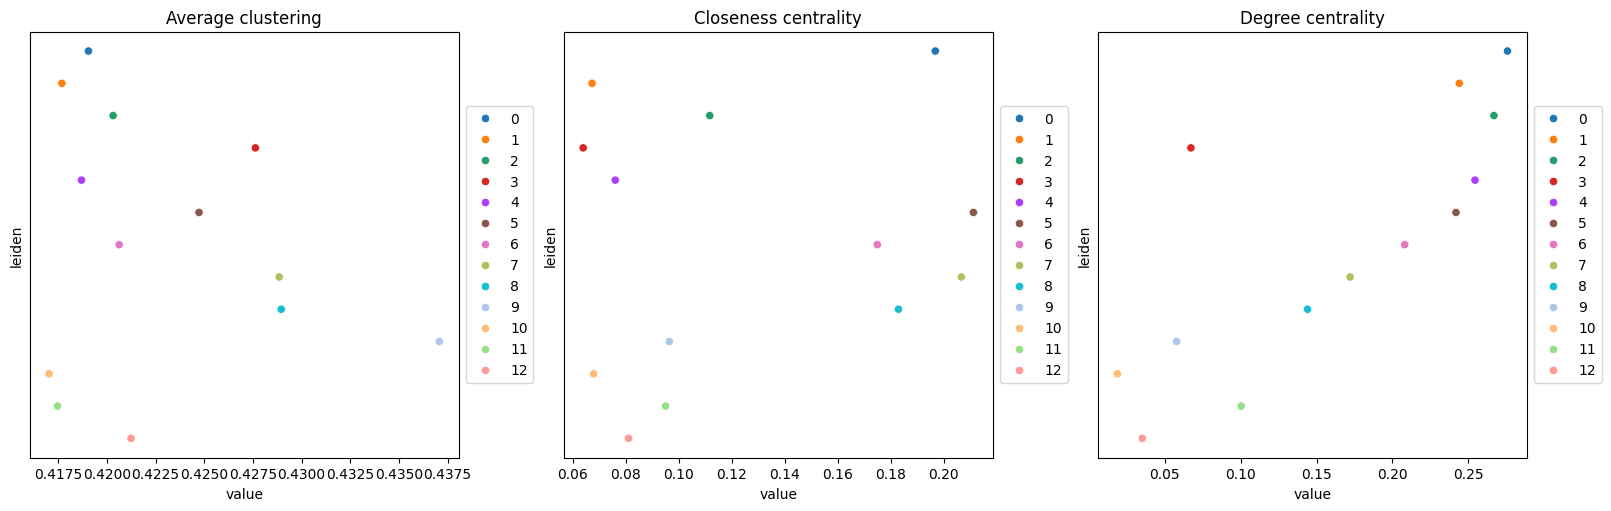

In [44]:
# Compute centrality scores
sq.gr.centrality_scores(adata, cluster_key="leiden")
sq.pl.centrality_scores(adata, cluster_key="leiden", figsize=(16, 5))

## Compute co-occurrence probability

/Users/whuan/opt/anaconda3/envs/celldega_env/lib/python3.11/site-packages/spatialdata/_core/_elements.py:125: UserWarning: Key `subsample` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)


  0%|          | 0/465 [00:00<?, ?/s]

/Users/whuan/opt/anaconda3/envs/celldega_env/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/whuan/opt/anaconda3/envs/celldega_env/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


/Users/whuan/opt/anaconda3/envs/celldega_env/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


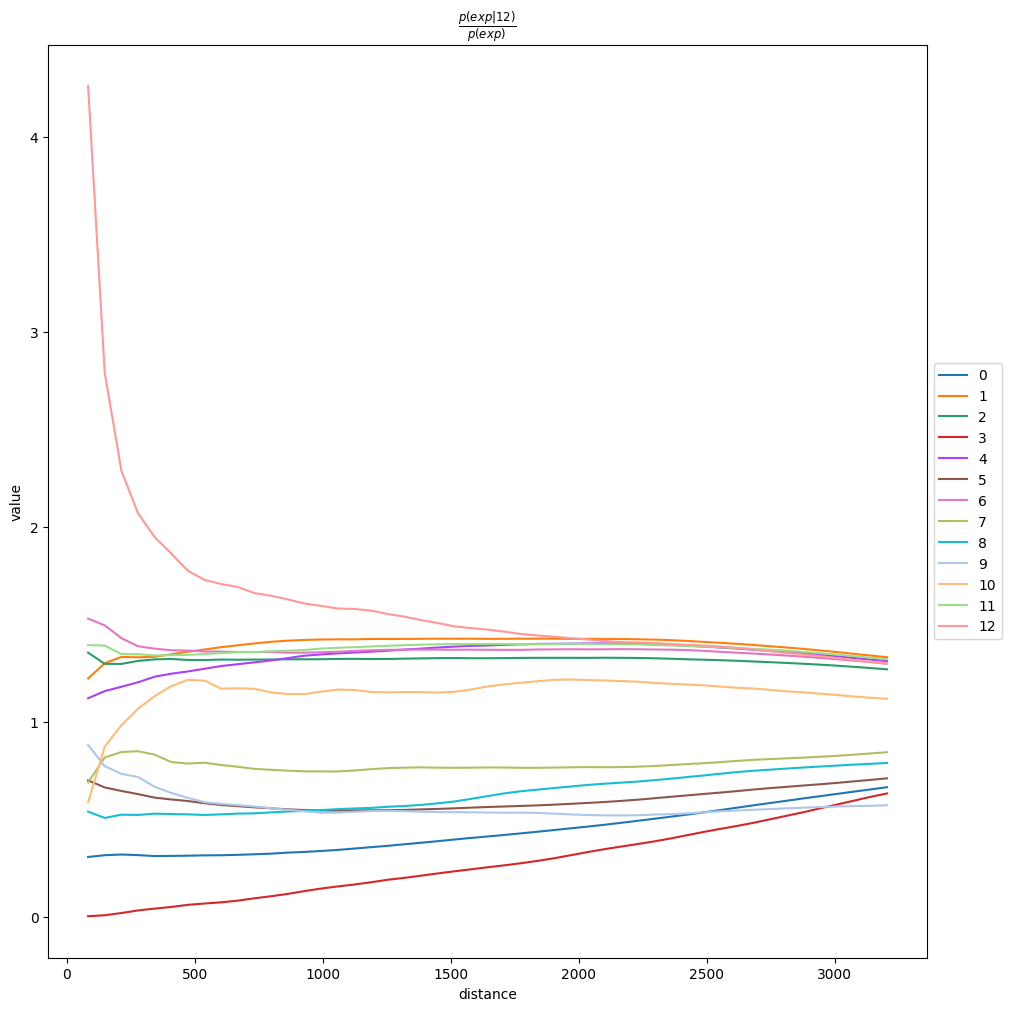

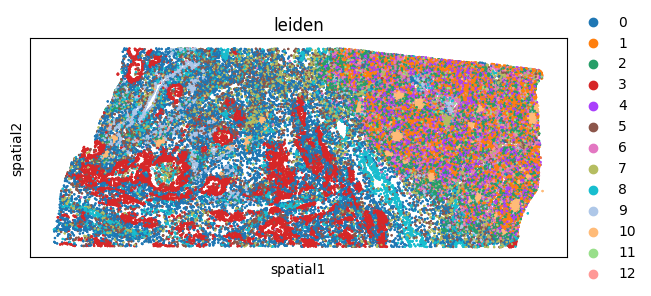

In [ ]:
adata.obs['cell_id'] = adata.obs.index # Add a cell_id column using index
sdata.tables["subsample"] = sc.pp.subsample(adata, fraction=0.5, copy=True)

adata_subsample = sdata.tables["subsample"]

sq.gr.co_occurrence(
    adata_subsample,
    cluster_key="leiden",
)
sq.pl.co_occurrence(
    adata_subsample,
    cluster_key="leiden",
    clusters="12",
    figsize=(10, 10),
)
sq.pl.spatial_scatter(
    adata_subsample,
    color="leiden",
    shape=None,
    size=2,
)

## Neighbors enrichment analysis

  0%|          | 0/1000 [00:00<?, ?/s]

/Users/whuan/opt/anaconda3/envs/celldega_env/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/whuan/opt/anaconda3/envs/celldega_env/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


/Users/whuan/opt/anaconda3/envs/celldega_env/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


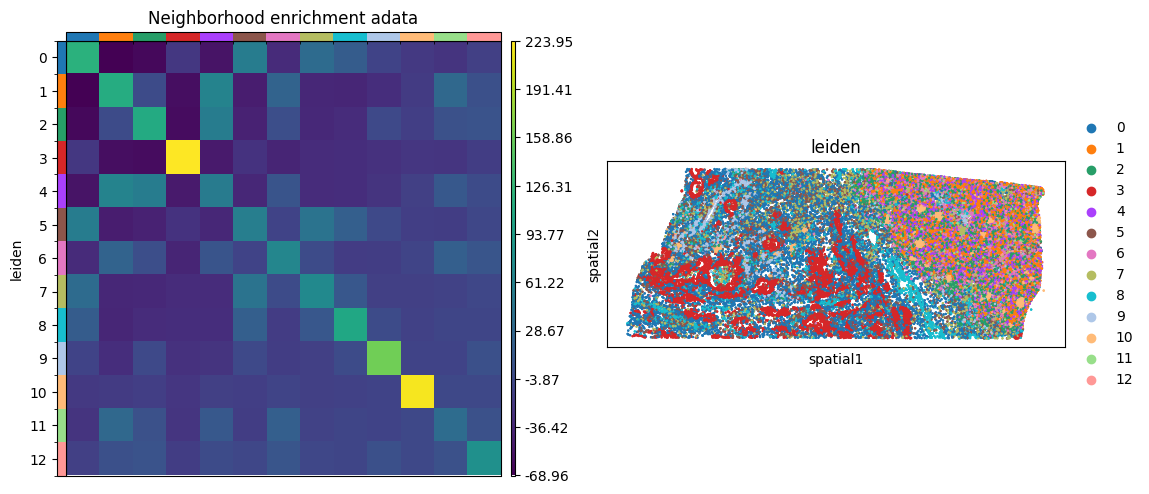

In [58]:
sq.gr.nhood_enrichment(adata_subsample, cluster_key="leiden")

fig, ax = plt.subplots(1, 2, figsize=(13, 7))
sq.pl.nhood_enrichment(
    adata_subsample,
    cluster_key="leiden",
    figsize=(8, 8),
    title="Neighborhood enrichment adata",
    ax=ax[0],
)
sq.pl.spatial_scatter(adata_subsample, color="leiden", shape=None, size=2, ax=ax[1])

## Compute Moran’s I score
The Moran’s I global spatial auto-correlation statistics evaluates whether features (i.e. genes) shows a pattern that is clustered, dispersed or random in the tissue are under consideration.

,I,pval_norm,var_norm,pval_z_sim,pval_sim,var_sim,pval_norm_fdr_bh,pval_z_sim_fdr_bh,pval_sim_fdr_bh
AMY2A,0.897936,0.0,0.000006,0.0,0.009901,0.000017,0.0,0.0,0.011311
INS,0.730406,0.0,0.000006,0.0,0.009901,0.000012,0.0,0.0,0.011311
GATM,0.697647,0.0,0.000006,0.0,0.009901,0.000012,0.0,0.0,0.011311
GCG,0.689413,0.0,0.000006,0.0,0.009901,0.000011,0.0,0.0,0.011311
GPRC5A,0.670420,0.0,0.000006,0.0,0.009901,0.000013,0.0,0.0,0.011311
SST,0.604548,0.0,0.000006,0.0,0.009901,0.000011,0.0,0.0,0.011311
CFTR,0.550828,0.0,0.000006,0.0,0.009901,0.000012,0.0,0.0,0.011311
COL17A1,0.509153,0.0,0.000006,0.0,0.009901,0.000009,0.0,0.0,0.011311
DMBT1,0.502107,0.0,0.000006,0.0,0.009901,0.000007,0.0,0.0,0.011311
GPX2,0.489595,0.0,0.000006,0.0,0.009901,0.000007,0.0,0.0,0.011311


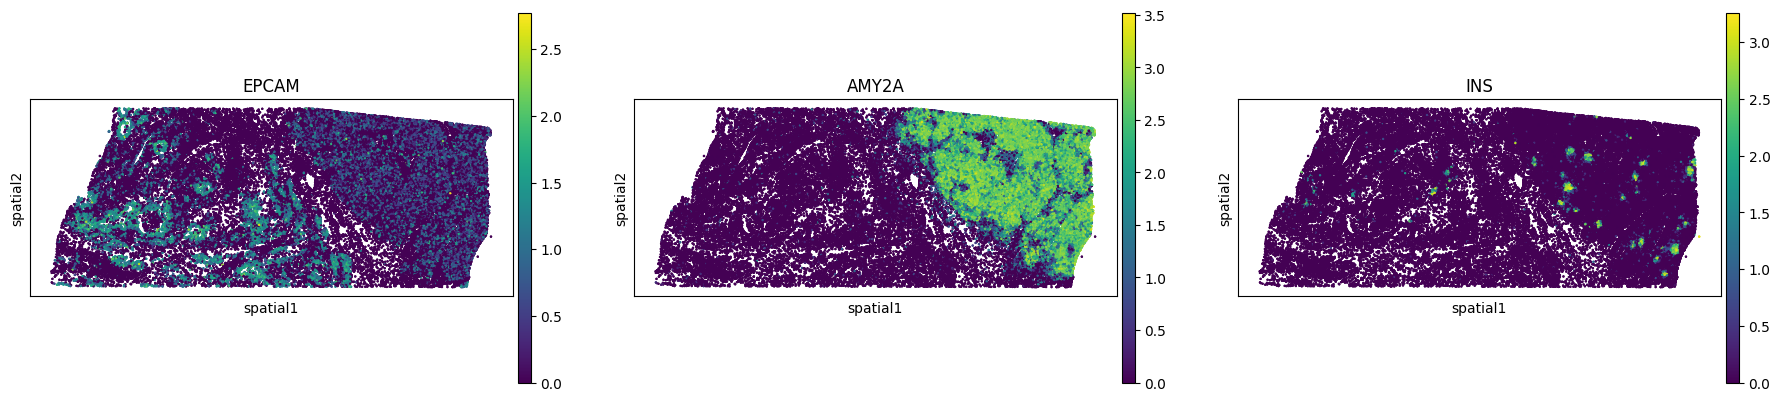

In [ ]:
sq.gr.spatial_neighbors(adata_subsample, coord_type="generic", delaunay=True)
sq.gr.spatial_autocorr(
    adata_subsample,
    mode="moran",
    n_perms=100,
    n_jobs=1,
)

sq.pl.spatial_scatter(
    adata_subsample,
    library_id="spatial",
    color=[
        "EPCAM",
        "AMY2A",
        "INS",
    ],
    shape=None,
    size=2,
    img=False,
)

adata_subsample.uns["moranI"].head(10)

In [ ]:
# adata_subsample.write_h5ad(f'{data_dir}_subsample_with_co_er_moran_.h5ad')